# The Measurement Maturity Ladder
### *All estimates vs. ground truth — what each level costs and buys*

This notebook assembles estimates from notebooks 01-03 and compares them
against the known ground truth. Because the data is synthetic, we can do
something impossible with real campaigns: measure exactly how wrong each
method is.

**Ground truth:** 1,340 USD/day = 71.6% of Nov pre-BF baseline
(computed from actual generated data — see writeup for discussion of the
circular ground truth caveat).

**Before/After and YoY** are auto-computed in the setup cell below.
**BSTS** and **BSTS+SC** estimates must be pasted from notebooks 02 and 03.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from utils import (
    get_treated_series, set_style, save_figure,
    usd_formatter, INTERVENTION_START, INTERVENTION_END,
    PALETTE, DATA_DIR
)
from generate_data import generate_dataset

set_style()
df, gt = generate_dataset(seed=42, data_dir=DATA_DIR)
ts     = get_treated_series(df)

TRUE_DAILY  = gt['true_increment_usd']    # 1,340 USD/day
PS_FULL_PRE = gt['ps_full_pre_mean_usd']  # 1,243 USD/day
PS_IMM_PRE  = gt['ps_imm_pre_mean_usd']   # 1,871 USD/day

# Auto-computed
bf_mask    = (ts.index >= INTERVENTION_START) & (ts.index <= INTERVENTION_END)
bf_mean    = ts[bf_mask].mean()
naive_full = bf_mean - ts[ts.index < INTERVENTION_START].mean()
naive_imm  = bf_mean - ts[(ts.index >= '2025-11-01') & (ts.index < INTERVENTION_START)].mean()
yoy        = bf_mean - ts[(ts.index >= '2024-11-28') & (ts.index <= '2024-12-03')].mean()

print(f'Ground truth:              {TRUE_DAILY:,.0f} USD/day')
print(f'Before/After (full pre):   {naive_full:,.0f} USD/day  ({(naive_full/TRUE_DAILY-1)*100:+.0f}%)')
print(f'Before/After (Nov base):   {naive_imm:,.0f} USD/day  ({(naive_imm/TRUE_DAILY-1)*100:+.0f}%)')
print(f'YoY (BF25 vs BF24):        {yoy:,.0f} USD/day  ({(yoy/TRUE_DAILY-1)*100:+.0f}%)')

Saved: dataset.csv  (4,386 rows)
Ground truth:              1,340 USD/day
Before/After (full pre):   2,998 USD/day  (+124%)
Before/After (Nov base):   2,370 USD/day  (+77%)
YoY (BF25 vs BF24):        2,187 USD/day  (+63%)


## 1. Paste estimates from notebooks 02 and 03

Run notebooks 02 and 03 first, then paste the printed values below.
NB02 prints `bsts_daily_effect` at the end of the Results cell.
NB03 prints `sc_v01_effect` and `sc_v02_effect` in the summary cell.

In [2]:
# ── FROM NOTEBOOK 02 ──────────────────────────────────────────────────────────
bsts_daily_effect = 2348   # e.g. 2348

# ── FROM NOTEBOOK 03 ──────────────────────────────────────────────────────────
sc_v01_effect = 1299   # e.g. 1352
sc_v02_effect = 1382   # e.g. 1318

# ── VALIDATION RESULTS FROM NB03 (optional — for display) ─────────────────────
# Paste from NB03 section 11 summary print
mape_v01      = 10.0   # e.g. 4.2  (pre-period MAPE %)
mape_v02      = 9.2   # e.g. 6.1
placebo_pct   = -5.4   # e.g. 1.3  (placebo effect %)
max_sens_swing= 17   # e.g. 8.2  (max sensitivity swing %)

missing = [k for k, v in {
    'bsts_daily_effect': bsts_daily_effect,
    'sc_v01_effect': sc_v01_effect,
    'sc_v02_effect': sc_v02_effect,
}.items() if v is None]

if missing:
    print(f'Still need from earlier notebooks: {missing}')
else:
    print('All estimates ready. Run the chart cells below.')

All estimates ready. Run the chart cells below.


## 2. Comparison chart

Saved: 04_maturity_ladder.png


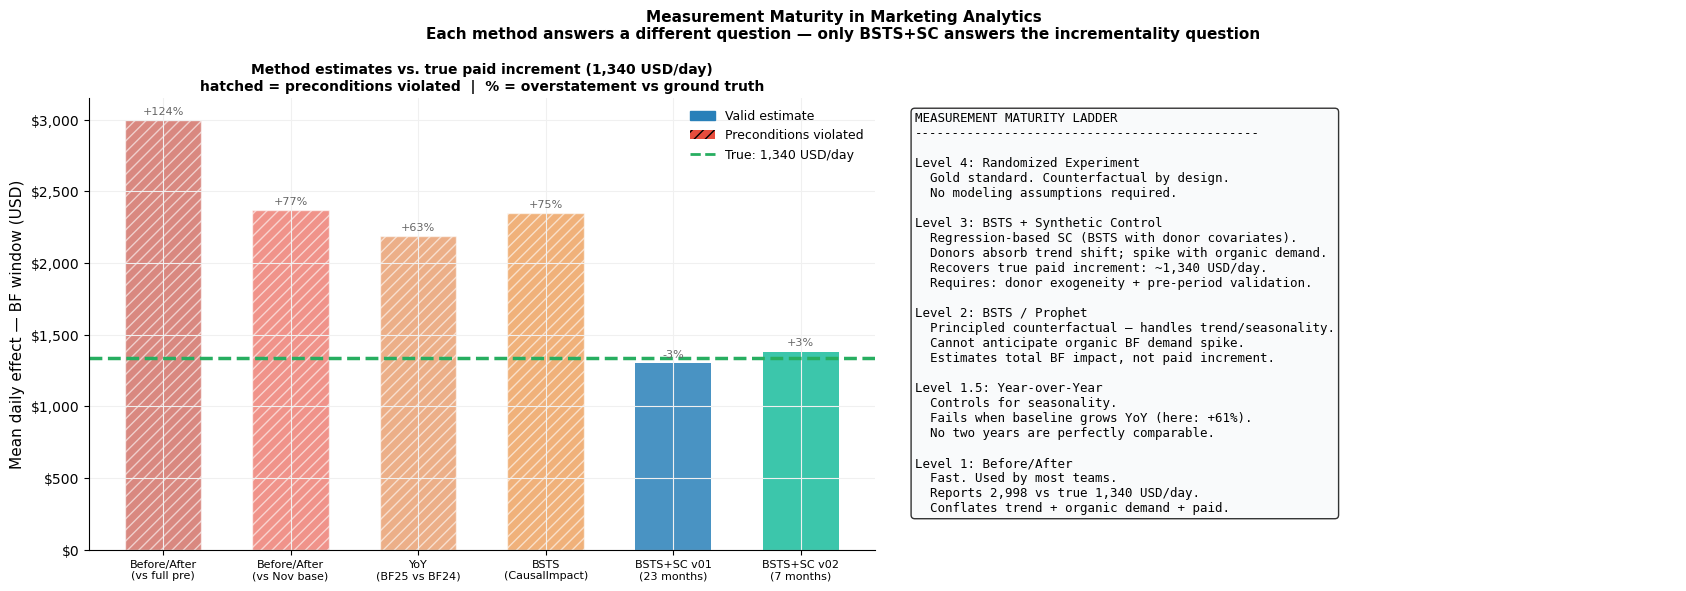

In [4]:
if any(v is None for v in [bsts_daily_effect, sc_v01_effect, sc_v02_effect]):
    print('Fill in estimates above first.')
else:
    ESTIMATES = {
        'Before/After\n(vs full pre)': {
            'daily_effect': naive_full,
            'color': '#c0392b', 'valid': False,
        },
        'Before/After\n(vs Nov base)': {
            'daily_effect': naive_imm,
            'color': '#e74c3c', 'valid': False,
        },
        'YoY\n(BF25 vs BF24)': {
            'daily_effect': yoy,
            'color': '#e07b39', 'valid': False,
        },
        'BSTS\n(CausalImpact)': {
            'daily_effect': bsts_daily_effect,
            'color': '#e67e22', 'valid': False,
        },
        'BSTS+SC v01\n(23 months)': {
            'daily_effect': sc_v01_effect,
            'color': '#2980b9', 'valid': True,
        },
        'BSTS+SC v02\n(7 months)': {
            'daily_effect': sc_v02_effect,
            'color': '#1abc9c', 'valid': True,
        },
    }

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    # Panel 1: bar chart
    ax = axes[0]
    labels = list(ESTIMATES.keys())
    vals   = [v['daily_effect'] for v in ESTIMATES.values()]
    colors = [v['color'] for v in ESTIMATES.values()]
    valid  = [v['valid'] for v in ESTIMATES.values()]

    bars = ax.bar(range(len(labels)), vals, color=colors, width=0.6, alpha=0.85)
    for bar, is_valid in zip(bars, valid):
        if not is_valid:
            bar.set_hatch('///')
            bar.set_edgecolor('white')
            bar.set_alpha(0.6)

    ax.axhline(TRUE_DAILY, color=PALETTE['truth'], lw=2.5, ls='--',
               label=f'True paid increment: {TRUE_DAILY:,.0f} USD/day')

    for idx, (k, v) in enumerate(ESTIMATES.items()):
        err  = v['daily_effect'] - TRUE_DAILY
        sign = '+' if err >= 0 else ''
        ax.text(idx, v['daily_effect'] + TRUE_DAILY * 0.03,
                f'{sign}{err/TRUE_DAILY*100:.0f}%',
                ha='center', fontsize=8, color=PALETTE['annotation'])

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Mean daily effect — BF window (USD)')
    ax.set_title(
        f'Method estimates vs. true paid increment ({TRUE_DAILY:,.0f} USD/day)\n'
        'hatched = preconditions violated  |  % = overstatement vs ground truth',
        fontsize=10
    )
    ax.yaxis.set_major_formatter(usd_formatter())

    valid_p   = mpatches.Patch(color='#2980b9', label='Valid estimate')
    invalid_p = mpatches.Patch(facecolor='#e74c3c', hatch='///',
                               label='Preconditions violated')
    truth_l   = plt.Line2D([0],[0], color=PALETTE['truth'], ls='--', lw=2,
                            label=f'True: {TRUE_DAILY:,.0f} USD/day')
    ax.legend(handles=[valid_p, invalid_p, truth_l], fontsize=9)

    # Panel 2: maturity ladder text
    ax2 = axes[1]
    ax2.axis('off')
    true_str  = f'{TRUE_DAILY:,.0f}'
    naive_str = f'{naive_full:,.0f}'

    ladder = (
        'MEASUREMENT MATURITY LADDER\n'
        '----------------------------------------------\n\n'
        'Level 4: Randomized Experiment\n'
        '  Gold standard. Counterfactual by design.\n'
        '  No modeling assumptions required.\n\n'
        'Level 3: BSTS + Synthetic Control\n'
        '  Regression-based SC (BSTS with donor covariates).\n'
        '  Donors absorb trend shift; spike with organic demand.\n'
        '  Recovers true paid increment: ~' + true_str + ' USD/day.\n'
        '  Requires: donor exogeneity + pre-period validation.\n\n'
        'Level 2: BSTS / Prophet\n'
        '  Principled counterfactual — handles trend/seasonality.\n'
        '  Cannot anticipate organic BF demand spike.\n'
        '  Estimates total BF impact, not paid increment.\n\n'
        'Level 1.5: Year-over-Year\n'
        '  Controls for seasonality.\n'
        '  Fails when baseline grows YoY (here: +61%).\n'
        '  No two years are perfectly comparable.\n\n'
        'Level 1: Before/After\n'
        '  Fast. Used by most teams.\n'
        '  Reports ' + naive_str + ' vs true ' + true_str + ' USD/day.\n'
        '  Conflates trend + organic demand + paid.'
    )
    ax2.text(0.03, 0.97, ladder, transform=ax2.transAxes,
             fontsize=9, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

    plt.suptitle(
        'Measurement Maturity in Marketing Analytics\n'
        'Each method answers a different question — only BSTS+SC answers the incrementality question',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    save_figure(fig, '04_maturity_ladder')
    plt.show()

## 3. Validation scorecard (from NB03)

In [5]:
if any(v is None for v in [mape_v01, mape_v02, placebo_pct, max_sens_swing]):
    print('Paste validation results from NB03 section 11 to display the scorecard.')
else:
    print('=== BSTS+SC Validation Scorecard ===')
    print()

    checks = [
        ('Pre-period MAPE v01',     f'{mape_v01:.1f}%',      mape_v01 < 15,    'threshold: <15%'),
        ('Pre-period MAPE v02',     f'{mape_v02:.1f}%',      mape_v02 < 15,    'threshold: <15%'),
        ('Placebo effect',          f'{placebo_pct:+.1f}%',  abs(placebo_pct) < 10, 'threshold: <10%'),
        ('Max sensitivity swing',   f'{max_sens_swing:.1f}%',max_sens_swing < 20,   'threshold: <20%'),
    ]

    for name, value, passed, note in checks:
        status = 'PASS' if passed else 'REVIEW'
        print(f'  {name:<28} {value:>8}   {status}  ({note})')

    all_pass = all(c[2] for c in checks)
    print()
    print(f'Overall: {"ALL PASS" if all_pass else "REVIEW REQUIRED"}')
    if all_pass:
        print('Counterfactual is credible. Estimate is decision-grade on this dataset.')
    else:
        print('One or more checks failed. Review before trusting the estimate.')

=== BSTS+SC Validation Scorecard ===

  Pre-period MAPE v01             10.0%   PASS  (threshold: <15%)
  Pre-period MAPE v02              9.2%   PASS  (threshold: <15%)
  Placebo effect                  -5.4%   PASS  (threshold: <10%)
  Max sensitivity swing           17.0%   PASS  (threshold: <20%)

Overall: ALL PASS
Counterfactual is credible. Estimate is decision-grade on this dataset.


## 4. What each method actually measures

In [6]:
questions = [
    ('Before/After',    'Did revenue go up?',
     f'{naive_full:,.0f} USD/day', f'+{(naive_full/TRUE_DAILY-1)*100:.0f}%'),
    ('YoY',             'Did revenue go up more than last year?',
     f'{yoy:,.0f} USD/day', f'+{(yoy/TRUE_DAILY-1)*100:.0f}%'),
    ('BSTS',            'Did revenue exceed the model forecast?',
     f'{bsts_daily_effect:,.0f} USD/day' if bsts_daily_effect else 'TBD',
     f'+{(bsts_daily_effect/TRUE_DAILY-1)*100:.0f}%' if bsts_daily_effect else 'TBD'),
    ('BSTS+SC',         'Did PS exceed organic demand alone?',
     f'~{TRUE_DAILY:,.0f} USD/day', '~0%'),
]

print(f'  {"Method":<14} {"Question answered":<42} {"Estimate":>16}  {"Error":>8}')
print('  ' + '-'*84)
for method, question, est, err in questions:
    print(f'  {method:<14} {question:<42} {est:>16}  {err:>8}')
print()
print(f'  True paid increment: {TRUE_DAILY:,.0f} USD/day')
print()
print('Only BSTS+SC most closely approximates the incrementality question.')
print('The others measure something real — just not campaign contribution specifically.')

  Method         Question answered                                  Estimate     Error
  ------------------------------------------------------------------------------------
  Before/After   Did revenue go up?                            2,998 USD/day     +124%
  YoY            Did revenue go up more than last year?        2,187 USD/day      +63%
  BSTS           Did revenue exceed the model forecast?        2,348 USD/day      +75%
  BSTS+SC        Did PS exceed organic demand alone?          ~1,340 USD/day       ~0%

  True paid increment: 1,340 USD/day

Only BSTS+SC most closely approximates the incrementality question.
The others measure something real — just not campaign contribution specifically.


## 5. Decision framework

In [7]:
print('''
You need to measure Paid Search incrementality for Black Friday.
|
+-- Can you run a geo holdout BEFORE the campaign?
    +-- YES -> Do it. Gold standard. No modeling assumptions required.
    |
    +-- NO  -> Do you have organic demand donor channels?
               (Organic Search, Direct, Referral, Social — NOT Email)
        |
        +-- YES -> At least 3 months of stable pre-period co-movement?
        |          |
        |          +-- YES -> BSTS+SC (regression-based SC)
        |          |          Run validation: MAPE, placebo, sensitivity
        |          |          Report estimate with credible interval
        |          |          Plan holdout to validate SC estimate
        |          |
        |          +-- NO  -> Before/After with decomposition
        |                     Label as directional only, not incrementality
        |                     Design holdout for next campaign NOW
        |
        +-- NO  -> BSTS / Prophet (if 1-2 years stable trend history)
                   Estimates total BF impact vs seasonal baseline
                   Cannot isolate paid increment from organic demand
                   Always plan a holdout for the next campaign
''')


You need to measure Paid Search incrementality for Black Friday.
|
+-- Can you run a geo holdout BEFORE the campaign?
    +-- YES -> Do it. Gold standard. No modeling assumptions required.
    |
    +-- NO  -> Do you have organic demand donor channels?
               (Organic Search, Direct, Referral, Social — NOT Email)
        |
        +-- YES -> At least 3 months of stable pre-period co-movement?
        |          |
        |          +-- YES -> BSTS+SC (regression-based SC)
        |          |          Run validation: MAPE, placebo, sensitivity
        |          |          Report estimate with credible interval
        |          |          Plan holdout to validate SC estimate
        |          |
        |          +-- NO  -> Before/After with decomposition
        |                     Label as directional only, not incrementality
        |                     Design holdout for next campaign NOW
        |
        +-- NO  -> BSTS / Prophet (if 1-2 years stable trend history)

## Summary

The progression is not about sophistication — it is about asking a more
precise question at each step. Only BSTS+SC most closely approximates
the incrementality question, and even it rests on assumptions that must
be explicitly validated.

A team reporting the before/after lift as campaign ROI will systematically
over-invest in paid channels and under-credit channels whose contribution
is harder to isolate. The error does not stay in the analysis —
it propagates into allocation decisions.

This is not a Black Friday problem. Black Friday just makes it visible.